# Predicción Automática de Correctitud de Pasajes Textuales Respecto a Preguntas Médicas

In [1]:
!pip install transformers torch pandas scikit-learn
!pip install spacy
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 7.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd 
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/ficheros necesarios/training_data.csv', sep=' ')
df

,topic,docId,correctness,passage
0,1,0113bb03-2a3a-4602-9394-d2fe911b624a,0,Tyler Perry Reveals Role Vitamin D Plays In Fi...
1,1,015c98bf-8632-4537-9038-7bc3e128cb97,0,This is why you should include Vitamin C and Z...
2,1,01e198e3-ec00-432d-92f0-cca8251db33d,0,Supplements for Coronavirus Probably Won’t Hel...
3,1,02700110-5195-4cee-b584-8fe6d870e2dd,0,Coronavirus: Top ways to protect yourself from...
4,1,02fb6095-115b-4418-bb34-8b76cc65059c,0,Coronavirus: It’s Time to Debunk Claims That V...
...,...,...,...,...
3490,25,fade068e-5598-4a5b-b194-fb90885c84a2,0,Would COVID-19 end in summer?: The DONG-A ILBO...
3491,25,fb6a1e79-37cf-4cbd-ad3f-48fa25dcf9ab,1,Coronavirus MORE POWERFUL than first thought a...
3492,25,fe95c08a-a416-44e9-b564-612daff46542,0,Good News: Chinese Scientists have Proven that...
3493,25,fef130d2-df1f-480b-9d0f-d34c6b247ab6,0,Don't Count on Warmer Weather to Curb COVID-19...


In [4]:
import re
import string
import spacy

# Cargar el modelo de spaCy
nlp = spacy.load('en_core_web_sm')

# Función para limpiar el texto
def clean_text(text):
    # Eliminar HTML y URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    # Eliminar hashtags
    text = re.sub(r'#\w+', '', text)
    # Eliminar caracteres no latinos
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Eliminar caracteres especiales y puntuación
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Convertir a minúsculas
    text = text.lower()

    # Reemplazar múltiples espacios por un solo espacio
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Procesar el texto con spaCy
    doc = nlp(text)
    
    # Eliminar stop words y lematizar
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    
    return ' '.join(tokens)

# Ejemplo de texto
df['cleaned_passage'] = df['passage'].apply(clean_text)

# Mostrar los primeros elementos de la columna limpiada
df

,topic,docId,correctness,passage,cleaned_passage
0,1,0113bb03-2a3a-4602-9394-d2fe911b624a,0,Tyler Perry Reveals Role Vitamin D Plays In Fi...,tyler perry reveal role vitamin d play fight c...
1,1,015c98bf-8632-4537-9038-7bc3e128cb97,0,This is why you should include Vitamin C and Z...,include vitamin c zinc daily diet orissapost h...
2,1,01e198e3-ec00-432d-92f0-cca8251db33d,0,Supplements for Coronavirus Probably Won’t Hel...,supplement coronavirus probably will not help ...
3,1,02700110-5195-4cee-b584-8fe6d870e2dd,0,Coronavirus: Top ways to protect yourself from...,coronavirus way protect vaccine develop mirror...
4,1,02fb6095-115b-4418-bb34-8b76cc65059c,0,Coronavirus: It’s Time to Debunk Claims That V...,coronavirus time debunk claim vitamin c cure m...
...,...,...,...,...,...
3490,25,fade068e-5598-4a5b-b194-fb90885c84a2,0,Would COVID-19 end in summer?: The DONG-A ILBO...,covid end summer donga ilbo content pdf voda n...
3491,25,fb6a1e79-37cf-4cbd-ad3f-48fa25dcf9ab,1,Coronavirus MORE POWERFUL than first thought a...,coronavirus powerful thought terrify superspre...
3492,25,fe95c08a-a416-44e9-b564-612daff46542,0,Good News: Chinese Scientists have Proven that...,good news chinese scientist prove warm weather...
3493,25,fef130d2-df1f-480b-9d0f-d34c6b247ab6,0,Don't Count on Warmer Weather to Curb COVID-19...,not count warm weather curb covid skip main co...


Como hay pasajes muy largos (más de 512 tokens), habrá que procesarlos de alguna forma. Para ello, se dividen en partes, se tokenizan y se combinan los embeddings usando una capa de atencion que depende de la dimension del vector de embeddings del modelo.

In [ ]:
import torch.nn as nn
from transformers import AutoModelForCausalLM, BertModel

class Attention(nn.Module):
    def __init__(self, embed_dim):
        super(Attention, self).__init__()
        # embed_dim: dimensión del vector de entrada
        # Crea una capa lineal que transforma cada vector a un único número (peso)
        self.attention = nn.Linear(embed_dim, 1)

    def forward(self, embeddings):
        # 1. Calcula pesos de atención
        weights = torch.softmax(self.attention(embeddings), dim=0)
        # 2. Multiplica cada embedding por su peso y suma
        weighted_sum = torch.sum(weights * embeddings, dim=0)
        return weighted_sum
    
def combine_embeddings_attention(embeddings, attention_layer):
    embeddings_tensor = torch.tensor(embeddings)
    return attention_layer(embeddings_tensor).detach().numpy()

# Determinar el tamaño del embedding para BioMedLM
biomed_model = AutoModelForCausalLM.from_pretrained("stanford-crfm/BioMedLM")
embed_dim_biomed = biomed_model.config.hidden_size

# Determinar el tamaño del embedding para ClinicalBERT
bert_model = BertModel.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
embed_dim_bert = bert_model.config.hidden_size # dimension del vector de embeddings del modelo

# Ejemplo de uso con BioMedLM
attention_layer_biomed = Attention(embed_dim=embed_dim_biomed)

# Ejemplo de uso con ClinicalBERT
attention_layer_bert = Attention(embed_dim=embed_dim_bert)



Aqui es donde dividimos los pasajes de más de 512 tokens en distintos bloques o *chunks*. Posteriormente, se extraen las representaciones de cada modelo y guardan como embedding, para luego combinar las que pertencen al mismo pasaje original.

In [55]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import numpy as np
import pandas as pd

# Configuración del dispositivo
device = torch.device('cpu')

# Función para dividir el texto en fragmentos de 512 tokens
def split_into_chunks(text, tokenizer, max_length=512):
    tokens = tokenizer.tokenize(text)
    chunks = [tokens[i:i + max_length] for i in range(0, len(tokens), max_length)]
    return chunks

# Función para procesar cada fragmento y combinar los resultados
def process_text(text, tokenizer, model, attention_layer, idx, model_type):
    start_time = time.time()
    
    chunks = split_into_chunks(text, tokenizer)
    embeddings = []
    
    for chunk in chunks:
        tokens = tokenizer.convert_tokens_to_ids(chunk)
        tokens_tensor = torch.tensor([tokens]).to(device)
        

        # Extraer la representación del [CLS] token (primer token)
        if model_type == 'biomed':
            with torch.no_grad():
                outputs = model(tokens_tensor, output_hidden_states=True)

            cls_embedding = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
            
        elif model_type == 'bert':
            with torch.no_grad():
                outputs = model(tokens_tensor)

            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        
        embeddings.append(cls_embedding)
    
    # Convertir la lista de arrays de NumPy a un solo array de NumPy
    embeddings_array = np.array(embeddings)

    # Combinar las representaciones
    combined_embedding = combine_embeddings_attention(embeddings_array, attention_layer)
    
    end_time = time.time()
    time_taken = end_time - start_time
    print(f"Pasaje {idx + 1} completado ({model_type}) - {time_taken:.2f} s")
    
    return combined_embedding

Ejecutamos lo anterior

In [56]:
from transformers import AutoTokenizer, BertTokenizer
import torch
import numpy as np
import pandas as pd
import time

# Cargar el tokenizador y el modelo de BioMedLM
biomed_tokenizer = AutoTokenizer.from_pretrained("stanford-crfm/BioMedLM")
bert_tokenizer = BertTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')


# Aplicar la función a cada elemento de la columna 'cleaned_passage'
#df['biomedlm_embeddings'] = df['cleaned_passage'].apply(lambda x: process_text(x, biomed_tokenizer, biomed_model, attention_layer=attention_layer_biomed))
#df['bioclinicalbert_embeddings'] = df['cleaned_passage'].apply(lambda x: process_text(x, bert_tokenizer, bert_model, attention_layer=attention_layer_bert))

embeddings_bert = [0] * len(df['cleaned_passage'])
embeddings_biomed = [0] * len(df['cleaned_passage'])

# Procesar cada pasaje y obtener los embeddings
for idx, text in enumerate(df['cleaned_passage']):
    embedding_biomed = process_text(text, biomed_tokenizer, biomed_model, attention_layer=attention_layer_biomed, idx=idx, model_type='biomed')
    embeddings_biomed[idx] = embedding_biomed

    embedding_bert = process_text(text, bert_tokenizer, bert_model, attention_layer=attention_layer_bert, idx=idx, model_type='bert')
    embeddings_bert[idx] = embedding_bert

# Añadir los embeddings al DataFrame
df['biomedlm_embeddings'] = embeddings_biomed
df['bioclinicalbert_embeddings'] = embeddings_bert

df['biomedlm_embeddings'] = df['biomedlm_embeddings'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
df['bioclinicalbert_embeddings'] = df['bioclinicalbert_embeddings'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

# Guardar el DataFrame como un archivo CSV
df.to_csv('embeddings.csv', index=False)

Pasaje 1 completado (biomed) - 30.77 s
Pasaje 1 completado (bert) - 0.15 s


KeyboardInterrupt: 

In [8]:
import ast
df3 = pd.read_csv('/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/embeddings.csv', sep=',')

# Convertir las listas de nuevo a arrays de NumPy
df3['biomedlm_embeddings'] = df3['biomedlm_embeddings'].apply(lambda x: np.array(ast.literal_eval(x)))
df3['bioclinicalbert_embeddings'] = df3['bioclinicalbert_embeddings'].apply(lambda x: np.array(ast.literal_eval(x)))
df3

,topic,docId,correctness,passage,cleaned_passage,biomedlm_embeddings,bioclinicalbert_embeddings
0,1,0113bb03-2a3a-4602-9394-d2fe911b624a,0,Tyler Perry Reveals Role Vitamin D Plays In Fi...,tyler perry reveal role vitamin d play fight c...,"[[-0.4583433270454407, -0.7408691644668579, -1...","[[-0.3204018771648407, -0.8082979321479797, -0..."
1,1,015c98bf-8632-4537-9038-7bc3e128cb97,0,This is why you should include Vitamin C and Z...,include vitamin c zinc daily diet orissapost h...,"[[-1.9723180532455444, -0.04033245891332626, -...","[[-0.29766371846199036, -0.8551684617996216, -..."
2,1,01e198e3-ec00-432d-92f0-cca8251db33d,0,Supplements for Coronavirus Probably Won’t Hel...,supplement coronavirus probably will not help ...,"[[-0.6690548658370972, 0.48831698298454285, -0...","[[0.03967305272817612, -0.708490788936615, -1...."
3,1,02700110-5195-4cee-b584-8fe6d870e2dd,0,Coronavirus: Top ways to protect yourself from...,coronavirus way protect vaccine develop mirror...,"[[0.5779121518135071, 0.7970146536827087, 1.01...","[[-0.4228624701499939, -0.768849790096283, -0...."
4,1,02fb6095-115b-4418-bb34-8b76cc65059c,0,Coronavirus: It’s Time to Debunk Claims That V...,coronavirus time debunk claim vitamin c cure m...,"[[1.5861400365829468, -0.59348064661026, -0.69...","[[-0.32800403237342834, -0.8866564035415649, -..."
...,...,...,...,...,...,...,...
3490,25,fade068e-5598-4a5b-b194-fb90885c84a2,0,Would COVID-19 end in summer?: The DONG-A ILBO...,covid end summer donga ilbo content pdf voda n...,"[[-1.6557223796844482, -0.9397992491722107, -1...","[[-0.25273436307907104, -1.1250349283218384, -..."
3491,25,fb6a1e79-37cf-4cbd-ad3f-48fa25dcf9ab,1,Coronavirus MORE POWERFUL than first thought a...,coronavirus powerful thought terrify superspre...,"[[1.5861400365829468, -0.59348064661026, -0.69...","[[-0.05073145031929016, -0.9243574142456055, -..."
3492,25,fe95c08a-a416-44e9-b564-612daff46542,0,Good News: Chinese Scientists have Proven that...,good news chinese scientist prove warm weather...,"[[0.5242543816566467, 1.0802795886993408, 0.15...","[[-0.19946515560150146, -0.667701244354248, -0..."
3493,25,fef130d2-df1f-480b-9d0f-d34c6b247ab6,0,Don't Count on Warmer Weather to Curb COVID-19...,not count warm weather curb covid skip main co...,"[[-0.19604650139808655, -0.44054627418518066, ...","[[0.20471042394638062, -0.5235592722892761, -0..."


In [9]:
X = np.array(df3['bioclinicalbert_embeddings'].tolist()).reshape(len(df3['bioclinicalbert_embeddings']), embed_dim_bert)
y = df3['correctness']
# Dividir los datos en conjuntos de entrenamiento y prueba
print("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Data split complete. Training size: {len(X_train)}, Test size: {len(X_test)}")

Splitting data into training and test sets...
Data split complete. Training size: 2621, Test size: 874


In [13]:
from sklearn.linear_model import LogisticRegression
# Entrenar el modelo de regresión logística
print("Training the logistic regression model...")
clf = LogisticRegression(max_iter=100000)  # Aumenta max_iter en caso de problemas de convergencia
clf.fit(X_train, y_train) 
print("Model training complete.")

Training the logistic regression model...
Model training complete.


In [14]:
# Predecir en el conjunto de prueba
print("Predicting on the test set...")
y_pred = clf.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification report:")
print(classification_report(y_test, y_pred))

Predicting on the test set...
Accuracy: 0.7116704805491991
Classification report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.74       468
           1       0.70      0.67      0.68       406

    accuracy                           0.71       874
   macro avg       0.71      0.71      0.71       874
weighted avg       0.71      0.71      0.71       874



In [20]:
!pip install xgboost

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 15.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb

# Dividir datos
X_biomedlm = np.array(df3['biomedlm_embeddings'].tolist()).reshape(len(df3['biomedlm_embeddings']), embed_dim_biomed)
X_bioclinical = np.array(df3['bioclinicalbert_embeddings'].tolist()).reshape(len(df3['bioclinicalbert_embeddings']), embed_dim_bert)
y = df3['correctness']

X_biomedlm_train, X_biomedlm_test, X_bioclinical_train, X_bioclinical_test, y_train, y_test = train_test_split(
    X_biomedlm, X_bioclinical, y, test_size=0.2, random_state=42
)

In [26]:
# Entrenar modelos para biomedlm
rf_biomedlm = RandomForestClassifier(random_state=42)
xgb_biomedlm = xgb.XGBClassifier(random_state=42)

rf_biomedlm.fit(X_biomedlm_train, y_train)
xgb_biomedlm.fit(X_biomedlm_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [27]:
# Entrenar modelos para bioclinical
rf_bioclinical = RandomForestClassifier(random_state=42)
xgb_bioclinical = xgb.XGBClassifier(random_state=42)

rf_bioclinical.fit(X_bioclinical_train, y_train)
xgb_bioclinical.fit(X_bioclinical_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [28]:
# Obtener predicciones
pred_rf_biomedlm = rf_biomedlm.predict(X_biomedlm_test)
pred_xgb_biomedlm = xgb_biomedlm.predict(X_biomedlm_test)
pred_rf_bioclinical = rf_bioclinical.predict(X_bioclinical_test)
pred_xgb_bioclinical = xgb_bioclinical.predict(X_bioclinical_test)

In [32]:
# Combinar predicciones usando votación mayoritaria
predictions = []
for i in range(len(y_test)):
    votes = [pred_rf_biomedlm[i], pred_rf_bioclinical[i]]
    pred = max(set(votes), key=votes.count)
    predictions.append(pred)

# Evaluar precisión combinada
combined_accuracy = accuracy_score(y_test, predictions)
print(f"Precisión del modelo combinado: {combined_accuracy:.4f}")

Precisión del modelo combinado: 0.6495


In [33]:
# Combinar predicciones usando votación mayoritaria
predictions = []
for i in range(len(y_test)):
    votes = pred_xgb_biomedlm[i], pred_xgb_bioclinical[i]
    pred = max(set(votes), key=votes.count)
    predictions.append(pred)

# Evaluar precisión combinada
combined_accuracy = accuracy_score(y_test, predictions)
print(f"Precisión del modelo combinado: {combined_accuracy:.4f}")

Precisión del modelo combinado: 0.6881


In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Concatenar embeddings
X_combined_train = np.concatenate((X_biomedlm_train, X_bioclinical_train), axis=1)
X_combined_test = np.concatenate((X_biomedlm_test, X_bioclinical_test), axis=1)

# Escalar los datos
scaler = StandardScaler()
X_combined_train_scaled = scaler.fit_transform(X_combined_train)
X_combined_test_scaled = scaler.transform(X_combined_test)

# Crear y entrenar MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # dos capas ocultas
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_combined_train_scaled, y_train)

# Predecir y evaluar
mlp_predictions = mlp.predict(X_combined_test_scaled)
mlp_accuracy = accuracy_score(y_test, mlp_predictions)
print(f"Precisión del modelo MLP: {mlp_accuracy:.4f}")

Precisión del modelo MLP: 0.7039


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Matplotlib is building the font cache; this may take a moment.


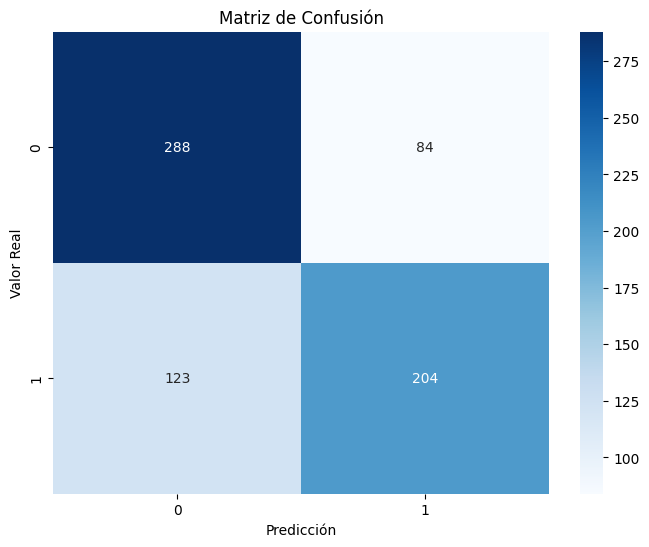


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.70      0.77      0.74       372
           1       0.71      0.62      0.66       327

    accuracy                           0.70       699
   macro avg       0.70      0.70      0.70       699
weighted avg       0.70      0.70      0.70       699



In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calcular matriz de confusión
cm = confusion_matrix(y_test, mlp_predictions)

# Crear visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

# Mostrar métricas detalladas
print("\nReporte de clasificación:")
print(classification_report(y_test, mlp_predictions))

In [42]:
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Escalar features
scaler = StandardScaler()
X_biomedlm_train_scaled = scaler.fit_transform(X_biomedlm_train)
X_biomedlm_test_scaled = scaler.transform(X_biomedlm_test)
X_bioclinical_train_scaled = scaler.fit_transform(X_bioclinical_train)
X_bioclinical_test_scaled = scaler.transform(X_bioclinical_test)

# Balancear datos con SMOTE
smote = SMOTE(random_state=42)
X_biomedlm_train_balanced, y_train_balanced = smote.fit_resample(X_biomedlm_train_scaled, y_train)
X_bioclinical_train_balanced, _ = smote.fit_resample(X_bioclinical_train_scaled, y_train)

# Parámetros para búsqueda
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'subsample': [0.8, 1.0]
}

# Búsqueda de mejores parámetros para cada modelo
xgb_biomedlm = xgb.XGBClassifier(random_state=42)
grid_search_biomedlm = GridSearchCV(xgb_biomedlm, param_grid, cv=5, scoring='accuracy')
grid_search_biomedlm.fit(X_biomedlm_train_balanced, y_train_balanced)

xgb_bioclinical = xgb.XGBClassifier(random_state=42)
grid_search_bioclinical = GridSearchCV(xgb_bioclinical, param_grid, cv=5, scoring='accuracy')
grid_search_bioclinical.fit(X_bioclinical_train_balanced, y_train_balanced)

# Usar los mejores modelos encontrados
best_xgb_biomedlm = grid_search_biomedlm.best_estimator_
best_xgb_bioclinical = grid_search_bioclinical.best_estimator_

# Predecir probabilidades
proba_biomedlm = best_xgb_biomedlm.predict_proba(X_biomedlm_test_scaled)
proba_bioclinical = best_xgb_bioclinical.predict_proba(X_bioclinical_test_scaled)

# Combinar predicciones con promedio ponderado
final_proba = 0.5 * proba_biomedlm + 0.5 * proba_bioclinical
predictions = np.argmax(final_proba, axis=1)

# Evaluar precisión
improved_accuracy = accuracy_score(y_test, predictions)
print(f"Precisión del modelo mejorado: {improved_accuracy:.4f}")
print(f"Mejores parámetros biomedlm: {grid_search_biomedlm.best_params_}")
print(f"Mejores parámetros bioclinical: {grid_search_bioclinical.best_params_}")

Precisión del modelo mejorado: 0.7253
Mejores parámetros biomedlm: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 0.8}
Mejores parámetros bioclinical: {'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}


PRIUEBA

In [ ]:
# Combinar predicciones con promedio ponderado
final_proba = 0.4 * proba_biomedlm + 0.6 * proba_bioclinical
predictions = np.argmax(final_proba, axis=1)

# Evaluar precisión
improved_accuracy = accuracy_score(y_test, predictions)
print(f"Precisión del modelo mejorado: {improved_accuracy:.4f}")

Precisión del modelo mejorado: 0.7310


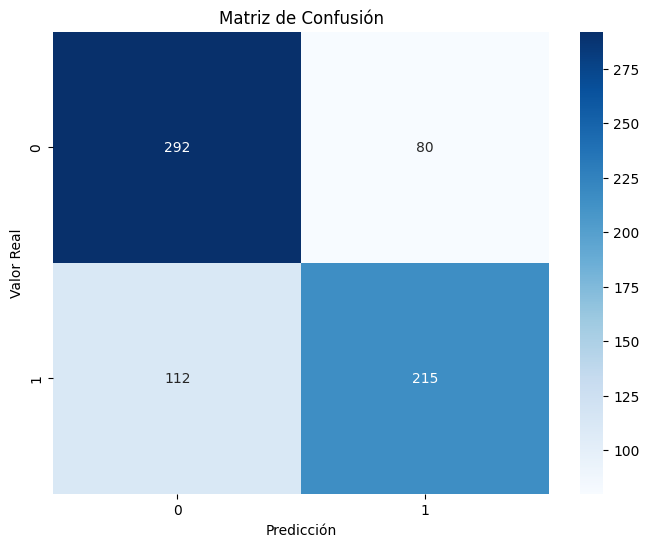


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.70      0.77      0.74       372
           1       0.71      0.62      0.66       327

    accuracy                           0.70       699
   macro avg       0.70      0.70      0.70       699
weighted avg       0.70      0.70      0.70       699



In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Calcular matriz de confusión
cm2 = confusion_matrix(y_test, predictions)

# Crear visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

# Mostrar métricas detalladas
print("\nReporte de clasificación:")
print(classification_report(y_test, mlp_predictions))

### TEST

In [45]:
df_test = pd.read_csv('/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/ficheros necesarios/test_data_with_no_correctness_label.csv', sep=' ')
df_test

,topic,docId,passage
0,27,0b60ca08-1e29-4286-9a52-bf70e51a3307,Coronavirus: Public can pose health questions ...
1,27,0bdd4e10-116d-4c20-abec-730ac1b57aa2,Coronavirus outbreak: Supreme Court's Offices ...
2,27,13b2be2c-ab67-4de1-a456-a7c57f29911b,"COVID-19: Food that relieves symptoms, dietiti..."
3,27,1f310f69-6e80-4158-94e8-17d5367f92ca,The myths and misinformation revolving around ...
4,27,2243553b-3ef2-45cc-8003-b4064bf7e013,TURMERIC – THE WONDER SPICE – Kaieteur News La...
...,...,...,...
1349,50,f60da83f-3162-460f-a35c-18eb1dc610e5,Cameroon's Coronavirus Cases Jump To 223 - Bre...
1350,50,f9a8c646-a14a-46fd-81a6-7cacbba07a54,Fact Check: Did BMC appeal to all citizens to ...
1351,50,fa9fd78d-8160-441f-acda-92365cdad997,AP NOT REAL NEWS: False coronavirus claims and...
1352,50,fc7d8362-114f-4536-a51f-07275536558a,FACT CHECK: Viral Image Claims No Israelis Hav...


In [46]:
df_test['cleaned_passage'] = df_test['passage'].apply(clean_text)
df_test

,topic,docId,passage,cleaned_passage
0,27,0b60ca08-1e29-4286-9a52-bf70e51a3307,Coronavirus: Public can pose health questions ...,coronavirus public pose health question volunt...
1,27,0bdd4e10-116d-4c20-abec-730ac1b57aa2,Coronavirus outbreak: Supreme Court's Offices ...,coronavirus outbreak supreme court office regi...
2,27,13b2be2c-ab67-4de1-a456-a7c57f29911b,"COVID-19: Food that relieves symptoms, dietiti...",covid food relieve symptom dietitian review va...
3,27,1f310f69-6e80-4158-94e8-17d5367f92ca,The myths and misinformation revolving around ...,myth misinformation revolve coronavirus outbre...
4,27,2243553b-3ef2-45cc-8003-b4064bf7e013,TURMERIC – THE WONDER SPICE – Kaieteur News La...,turmeric wonder spice kaieteur news late updat...
...,...,...,...,...
1349,50,f60da83f-3162-460f-a35c-18eb1dc610e5,Cameroon's Coronavirus Cases Jump To 223 - Bre...,cameroon coronavirus case jump breaking time b...
1350,50,f9a8c646-a14a-46fd-81a6-7cacbba07a54,Fact Check: Did BMC appeal to all citizens to ...,fact check bmc appeal citizen drink boil water...
1351,50,fa9fd78d-8160-441f-acda-92365cdad997,AP NOT REAL NEWS: False coronavirus claims and...,ap real news false coronavirus claim phony rem...
1352,50,fc7d8362-114f-4536-a51f-07275536558a,FACT CHECK: Viral Image Claims No Israelis Hav...,fact check viral image claim israelis die covi...


In [57]:
# Cargar el tokenizador y el modelo de BioMedLM
biomed_tokenizer = AutoTokenizer.from_pretrained("stanford-crfm/BioMedLM")
bert_tokenizer = BertTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')

embeddings_bert_test = [0] * len(df_test['cleaned_passage'])
embeddings_biomed_test = [0] * len(df_test['cleaned_passage'])

# Procesar cada pasaje y obtener los embeddings
for idx, text in enumerate(df_test['cleaned_passage']):
    embedding_biomed = process_text(text, biomed_tokenizer, biomed_model, attention_layer=attention_layer_biomed, idx=idx, model_type='biomed')
    embeddings_biomed_test[idx] = embedding_biomed

    embedding_bert = process_text(text, bert_tokenizer, bert_model, attention_layer=attention_layer_bert, idx=idx, model_type='bert')
    embeddings_bert_test[idx] = embedding_bert

# Añadir los embeddings al DataFrame
df_test['biomedlm_embeddings'] = embeddings_biomed_test
df_test['bioclinicalbert_embeddings'] = embeddings_bert_test

df_test['biomedlm_embeddings'] = df_test['biomedlm_embeddings'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
df_test['bioclinicalbert_embeddings'] = df_test['bioclinicalbert_embeddings'].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

# Guardar el DataFrame como un archivo CSV
df_test.to_csv('embeddings_test.csv', index=False)

Pasaje 1 completado (biomed) - 32.18 s
Pasaje 1 completado (bert) - 0.22 s
Pasaje 2 completado (biomed) - 33.79 s
Pasaje 2 completado (bert) - 0.20 s
Pasaje 3 completado (biomed) - 33.02 s
Pasaje 3 completado (bert) - 0.37 s
Pasaje 4 completado (biomed) - 33.43 s
Pasaje 4 completado (bert) - 0.34 s
Pasaje 5 completado (biomed) - 32.36 s
Pasaje 5 completado (bert) - 0.28 s
Pasaje 6 completado (biomed) - 36.09 s
Pasaje 6 completado (bert) - 0.41 s
Pasaje 7 completado (biomed) - 33.56 s
Pasaje 7 completado (bert) - 0.20 s
Pasaje 8 completado (biomed) - 33.94 s
Pasaje 8 completado (bert) - 0.24 s
Pasaje 9 completado (biomed) - 33.60 s
Pasaje 9 completado (bert) - 0.24 s
Pasaje 10 completado (biomed) - 64.95 s
Pasaje 10 completado (bert) - 0.32 s
Pasaje 11 completado (biomed) - 30.85 s
Pasaje 11 completado (bert) - 0.15 s
Pasaje 12 completado (biomed) - 37.64 s
Pasaje 12 completado (bert) - 0.26 s
Pasaje 13 completado (biomed) - 32.30 s
Pasaje 13 completado (bert) - 0.18 s
Pasaje 14 complet

Token indices sequence length is longer than the specified maximum sequence length for this model (1235 > 1024). Running this sequence through the model will result in indexing errors


Pasaje 64 completado (biomed) - 101.18 s
Pasaje 64 completado (bert) - 0.70 s
Pasaje 65 completado (biomed) - 29.65 s
Pasaje 65 completado (bert) - 0.13 s
Pasaje 66 completado (biomed) - 34.05 s
Pasaje 66 completado (bert) - 0.26 s
Pasaje 67 completado (biomed) - 63.88 s
Pasaje 67 completado (bert) - 0.38 s
Pasaje 68 completado (biomed) - 65.52 s
Pasaje 68 completado (bert) - 0.27 s
Pasaje 69 completado (biomed) - 33.95 s
Pasaje 69 completado (bert) - 0.25 s
Pasaje 70 completado (biomed) - 32.24 s
Pasaje 70 completado (bert) - 0.26 s
Pasaje 71 completado (biomed) - 106.29 s
Pasaje 71 completado (bert) - 1.12 s
Pasaje 72 completado (biomed) - 139.09 s
Pasaje 72 completado (bert) - 0.37 s
Pasaje 73 completado (biomed) - 150.09 s
Pasaje 73 completado (bert) - 0.40 s
Pasaje 74 completado (biomed) - 45.95 s
Pasaje 74 completado (bert) - 0.39 s
Pasaje 75 completado (biomed) - 67.63 s
Pasaje 75 completado (bert) - 0.19 s
Pasaje 76 completado (biomed) - 2870.57 s
Pasaje 76 completado (bert) - 

In [58]:
import ast
df3_test = pd.read_csv('/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/embeddings_test.csv', sep=',')

# Convertir las listas de nuevo a arrays de NumPy
df3_test['biomedlm_embeddings'] = df3_test['biomedlm_embeddings'].apply(lambda x: np.array(ast.literal_eval(x)))
df3_test['bioclinicalbert_embeddings'] = df3_test['bioclinicalbert_embeddings'].apply(lambda x: np.array(ast.literal_eval(x)))
df3_test

,topic,docId,passage,cleaned_passage,biomedlm_embeddings,bioclinicalbert_embeddings
0,27,0b60ca08-1e29-4286-9a52-bf70e51a3307,Coronavirus: Public can pose health questions ...,coronavirus public pose health question volunt...,"[[1.5861400365829468, -0.59348064661026, -0.69...","[[-0.574562132358551, -0.5748574733734131, -0...."
1,27,0bdd4e10-116d-4c20-abec-730ac1b57aa2,Coronavirus outbreak: Supreme Court's Offices ...,coronavirus outbreak supreme court office regi...,"[[1.5861400365829468, -0.59348064661026, -0.69...","[[0.03315418213605881, -0.4734562039375305, -0..."
2,27,13b2be2c-ab67-4de1-a456-a7c57f29911b,"COVID-19: Food that relieves symptoms, dietiti...",covid food relieve symptom dietitian review va...,"[[-1.6557223796844482, -0.9397992491722107, -1...","[[-0.4335113763809204, -0.6927109956741333, -1..."
3,27,1f310f69-6e80-4158-94e8-17d5367f92ca,The myths and misinformation revolving around ...,myth misinformation revolve coronavirus outbre...,"[[-1.1994397640228271, 1.6967610120773315, 0.9...","[[-0.5427172780036926, -0.5940972566604614, -0..."
4,27,2243553b-3ef2-45cc-8003-b4064bf7e013,TURMERIC – THE WONDER SPICE – Kaieteur News La...,turmeric wonder spice kaieteur news late updat...,"[[-3.2705748081207275, 0.023014232516288757, 0...","[[-0.028344448655843735, -0.7062832713127136, ..."
...,...,...,...,...,...,...
1349,50,f60da83f-3162-460f-a35c-18eb1dc610e5,Cameroon's Coronavirus Cases Jump To 223 - Bre...,cameroon coronavirus case jump breaking time b...,"[[-1.894892692565918, 0.7013649940490723, -1.4...","[[-0.1328793168067932, -0.8305183053016663, -0..."
1350,50,f9a8c646-a14a-46fd-81a6-7cacbba07a54,Fact Check: Did BMC appeal to all citizens to ...,fact check bmc appeal citizen drink boil water...,"[[-0.4696310758590698, 0.14062070846557617, -2...","[[-0.3999641537666321, -0.26502805948257446, -..."
1351,50,fa9fd78d-8160-441f-acda-92365cdad997,AP NOT REAL NEWS: False coronavirus claims and...,ap real news false coronavirus claim phony rem...,"[[-0.6170236468315125, 1.6426397562026978, -1....","[[-0.3383338451385498, -0.6347936987876892, -0..."
1352,50,fc7d8362-114f-4536-a51f-07275536558a,FACT CHECK: Viral Image Claims No Israelis Hav...,fact check viral image claim israelis die covi...,"[[-0.4696310758590698, 0.14062070846557617, -2...","[[-0.03054194524884224, -1.2140341997146606, -..."


In [74]:
X_biomedlm_test_test = np.array(df3_test['biomedlm_embeddings'].tolist()).reshape(len(df3_test['biomedlm_embeddings']), embed_dim_biomed)
X_bioclinical_test_test = np.array(df3_test['bioclinicalbert_embeddings'].tolist()).reshape(len(df3_test['bioclinicalbert_embeddings']), embed_dim_bert)

scaler = StandardScaler()
X_biomedlm_train_scaled = scaler.fit_transform(X_biomedlm_train)
X_biomedlm_scaled_test = scaler.transform(X_biomedlm_test_test)
X_bioclinical_train_scaled = scaler.fit_transform(X_bioclinical_train)
X_bioclinical_scaled_test = scaler.transform(X_bioclinical_test_test)

In [87]:
# Predecir probabilidades
proba_biomedlm_test = best_xgb_biomedlm.predict_proba(X_biomedlm_scaled_test)
proba_bioclinical_test = best_xgb_bioclinical.predict_proba(X_bioclinical_scaled_test)

# Combinar predicciones con promedio ponderado
final_proba_test = 0.5 * proba_biomedlm_test + 0.5 * proba_bioclinical_test
predictions_test = np.argmax(final_proba_test, axis=1)
predictions_test

import pandas as pd

# Crear el DataFrame
df_result = pd.DataFrame({
    'topic': df3_test['topic'],
    'docId': df3_test['docId'],
    'correctness': predictions_test
})

# Guardar en un archivo CSV con separador de espacio
df_result.to_csv('prediccionesCombinadas.csv', sep=' ', index=False)

print("Archivo guardado como 'resultados.csv'")

Archivo guardado como 'resultados.csv'


In [93]:
import pandas as pd

# Cargar los archivos CSV
file_paths = [
    '/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/prediccionesCombinadas03_07.csv',
    '/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/prediccionesCombinadas04_06.csv',
    '/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/prediccionesLR.csv',
    '/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/prediccionesRF.csv',
    '/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/prediccionesSVM.csv',
    '/Users/luisi/Documents/Master/1. Tecnologías de gestión de información no estructurada/Practica/Reto/prediccionesXGB.csv'
]

# Leer los archivos en DataFrames
dfs = [pd.read_csv(file_path, sep=' ') for file_path in file_paths]

# Asegurarse de que los DataFrames tengan las mismas filas y columnas
for df in dfs:
    assert df.shape == dfs[0].shape, "Los archivos CSV no tienen el mismo número de filas y columnas"

# Concatenar las columnas 'correctness' de cada DataFrame
correctness_df = pd.concat([df['correctness'] for df in dfs], axis=1)
correctness_df.columns = [f'correctness_{i+1}' for i in range(len(dfs))]

# Encontrar las filas donde las 5 columnas no son iguales
mismatched_rows = correctness_df[~correctness_df.apply(lambda row: row.nunique() == 1, axis=1)]

claves = ['0307', '0406', 'LR', 'RF', 'SVM', 'XGB']
# Crear una nueva tabla con las filas donde las 5 columnas 'correctness' no son iguales
if not mismatched_rows.empty:
    mismatched_indices = mismatched_rows.index
    mismatched_data = pd.concat([df.loc[mismatched_indices, ['correctness']] for df in dfs], axis=1, keys=claves)
    mismatched_data = mismatched_data.loc[:,~mismatched_data.columns.duplicated()]  # Eliminar columnas duplicadas

    # Guardar la nueva tabla en un archivo CSV
    mismatched_data.to_csv('mismatched_rows.csv', sep=' ', index=False)
    print("Archivo guardado como 'mismatched_rows.csv'")
else:
    print("No hay filas donde las 5 columnas 'correctness' no son iguales.")

Archivo guardado como 'mismatched_rows.csv'
